# Capstone Project — Summer Semester OMDS 2026
## Olist E-Commerce Dataset: Predicting Customer Satisfaction

This notebook analyses a marketing dataset from the Brazilian e-commerce start-up 'Olist'. Olist operates on a 'store-within-a-store' model which connects small and medium-sized business to major online marketplaces.

For this project, I wanted to look at which operational, product, seller, and financial variables were able to best predict customer satisfaction based on a review score from 1-5.

### Key

**Key Stakeholders**
- Marketing analytics teams:
- Shareholders:

**Secondary Audience:**
Olist Operations & Logistics Leadership — seeking data-driven ways to reduce delivery delays and improve gross merchandise volume.


### Analytical Approach
This notebook progresses through seven modelling weeks, building from simple linear regression through ensemble tree methods. Each week uses the same extended feature set — covering logistics, product, seller, and payment dimensions — allowing direct model comparison on a consistent basis.

# 1. Load Required Libraries

In [1]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Load Dataset

Downloading the Brazilian E-Commerce Public Dataset by Olist from Kaggle.

In [2]:
# Download dataset via kagglehub
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset downloaded to:", dataset_path)

# List available CSV files
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
print(f"\nFiles available ({len(csv_files)} CSVs):")
for f in sorted(csv_files):
    print(f"  {f}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset downloaded to: /kaggle/input/brazilian-ecommerce

Files available (9 CSVs):
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


In [3]:
# Load each CSV into a named DataFrame
orders        = pd.read_csv(os.path.join(dataset_path, "olist_orders_dataset.csv"))
order_items   = pd.read_csv(os.path.join(dataset_path, "olist_order_items_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(dataset_path, "olist_order_reviews_dataset.csv"))
customers     = pd.read_csv(os.path.join(dataset_path, "olist_customers_dataset.csv"))
products      = pd.read_csv(os.path.join(dataset_path, "olist_products_dataset.csv"))
sellers       = pd.read_csv(os.path.join(dataset_path, "olist_sellers_dataset.csv"))
payments      = pd.read_csv(os.path.join(dataset_path, "olist_order_payments_dataset.csv"))
geo           = pd.read_csv(os.path.join(dataset_path, "olist_geolocation_dataset.csv"))
product_names = pd.read_csv(os.path.join(dataset_path, "product_category_name_translation.csv"))

print("All datasets loaded successfully.")
print(f"  orders:        {orders.shape}")
print(f"  order_items:   {order_items.shape}")
print(f"  order_reviews: {order_reviews.shape}")
print(f"  customers:     {customers.shape}")
print(f"  products:      {products.shape}")
print(f"  sellers:       {sellers.shape}")
print(f"  payments:      {payments.shape}")

All datasets loaded successfully.
  orders:        (99441, 8)
  order_items:   (112650, 7)
  order_reviews: (99224, 7)
  customers:     (99441, 5)
  products:      (32951, 9)
  sellers:       (3095, 4)
  payments:      (103886, 5)


# 3. Build Master DataFrame

Merging all relational tables into one master DataFrame. The payments table is aggregated per order before joining to avoid row duplication from multiple payment methods.

In [4]:
# Aggregate payments to one row per order
payments_agg = payments.groupby('order_id').agg(
    payment_type         = ('payment_type',         lambda x: x.mode()[0]),  # most common method
    payment_installments = ('payment_installments', 'max'),                   # max installments used
    payment_value        = ('payment_value',        'sum')                    # total amount paid
).reset_index()

# Build master DataFrame through sequential left joins
df = pd.merge(orders,        order_items,   on='order_id',   how='left')
df = pd.merge(df,            order_reviews, on='order_id',   how='left')
df = pd.merge(df,            customers,     on='customer_id', how='left')
df = pd.merge(df,            products,      on='product_id',  how='left')
df = pd.merge(df,            product_names, on='product_category_name', how='left')
df = pd.merge(df,            sellers,       on='seller_id',  how='left')
df = pd.merge(df,            payments_agg,  on='order_id',   how='left')

print(f"Master DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.info()

Master DataFrame: 114,092 rows × 39 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   order_item_id                  113314 non-null  float64
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null 

# 4. Exploratory Data Analysis (EDA)

In [5]:
# Preview and summary statistics
display(df.head())
display(df.describe())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,housewares,9350.0,maua,SP,voucher,1.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,auto,14840.0,guariba,SP,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,credit_card,1.0,28.62


,order_item_id,price,freight_value,review_score,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_installments,payment_value
count,113314.000000,113314.000000,113314.000000,113131.000000,114092.000000,111702.000000,111702.000000,111702.000000,113296.000000,113296.000000,113296.000000,113296.000000,113314.000000,114089.000000,114089.000000
mean,1.198528,120.478701,19.979428,4.016998,35105.227308,48.777560,786.899250,2.206908,2091.915037,30.162495,16.584513,23.003539,24441.665655,3.020878,180.382544
std,0.707016,183.279678,15.783227,1.400074,29868.300916,10.024616,651.758866,1.719500,3749.804597,16.151737,13.439206,11.708481,27597.244696,2.806454,273.066275
min,1.000000,0.850000,0.000000,1.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,0.000000,0.000000
25%,1.000000,39.900000,13.080000,4.000000,11250.000000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,65.630000
50%,1.000000,74.900000,16.260000,5.000000,24320.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13568.000000,2.000000,114.330000
75%,1.000000,134.900000,21.150000,5.000000,59022.000000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27930.000000,4.000000,195.390000
max,21.000000,6735.000000,409.680000,5.000000,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,24.000000,13664.080000


In [6]:
# Data quality check
print("Unique values per column:")
display(df.nunique().to_frame("unique_count"))

print("\nNull values per column:")
display(df.isnull().sum().to_frame("null_count"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Unique values per column:


,unique_count
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
order_item_id,21
product_id,32951



Null values per column:


,null_count
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,162
order_delivered_carrier_date,1980
order_delivered_customer_date,3253
order_estimated_delivery_date,0
order_item_id,778
product_id,778



Duplicate rows: 0


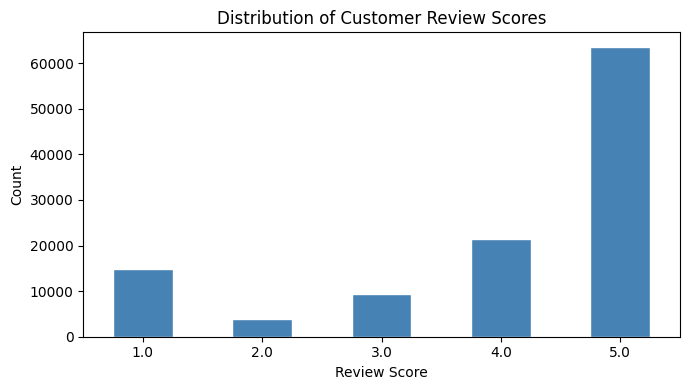


Class counts:
review_score
1.0    14775
2.0     3936
3.0     9476
4.0    21348
5.0    63596
Name: count, dtype: int64


In [7]:
# Target variable distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['review_score'].dropna().value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlabel("Review Score")
ax.set_ylabel("Count")
ax.set_title("Distribution of Customer Review Scores")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("review_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClass counts:")
print(df['review_score'].value_counts().sort_index())

### EDA Summary
The dataset joins order, item, review, customer, product, seller, and payment information. The target variable `review_score` is heavily skewed toward 5-star ratings, with 1-star reviews being the second most common — a U-shaped distribution typical of review platforms where only strongly satisfied or strongly dissatisfied customers leave feedback.

Key data quality notes:
- Review-related fields (`review_comment_message`) have high missingness — these are optional fields
- Product dimension fields have some nulls (items with no physical spec on file)
- All other core join keys are complete

# 5. Feature Engineering

Features are organised into four groups:
1. **Logistics** — delivery timing, delays, order pipeline stage
2. **Product** — category, listing quality (description length, photo count), physical attributes
3. **Seller** — geographic frequency, historical performance, experience volume
4. **Payment** — method, installment count, total value, price tier

Note on `seller_avg_score`: this is computed from the full dataset's review scores and therefore constitutes a mild data leakage risk. In a production deployment, this would be computed from historical orders only. It is retained here for its strong signal value in analysis but should be interpreted with this caveat in mind.

In [8]:
# ── Parse datetime columns ──────────────────────────────────────────────────
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# ── GROUP 1: Logistics features ──────────────────────────────────────────────
# Total delivery time (days from purchase to receipt)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Delivery relative to promised date (negative = early, positive = late)
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# Time from purchase to payment approval
df['approval_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Time from approval to carrier pickup (seller's handoff speed)
df['carrier_handoff_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds() / 86400

# Time for Olist to respond to the review
df['review_response_days'] = (
    df['review_answer_timestamp'] - df['review_creation_date']
).dt.total_seconds() / 86400

# Order status — ordinal encoding reflecting pipeline progress
status_order = {
    'created': 0, 'approved': 1, 'processing': 2, 'invoiced': 3,
    'shipped': 4, 'delivered': 5, 'unavailable': -1, 'canceled': -2
}
df['order_status_enc'] = df['order_status'].map(status_order)

# Customer state — frequency encoding avoids 27 dummy variables
state_freq = df['customer_state'].value_counts(normalize=True)
df['customer_state_freq'] = df['customer_state'].map(state_freq)

# Binary: did the customer leave a written comment? (strong signal for dissatisfaction)
df['has_comment'] = df['review_comment_message'].notna().astype(int)

# ── GROUP 2: Product features ────────────────────────────────────────────────
# Listing quality proxies
# Note: Olist dataset has a known typo in column name 'product_description_lenght'
df['description_length'] = df['product_description_lenght'].fillna(0)
df['photo_count']        = df['product_photos_qty'].fillna(0)

# Physical attributes — heavier/larger items carry more shipping risk
df['weight_kg']  = df['product_weight_g'].fillna(0) / 1000
df['volume_cm3'] = (
    df['product_length_cm'].fillna(0) *
    df['product_height_cm'].fillna(0) *
    df['product_width_cm'].fillna(0)
)

# Product category — frequency encode to avoid 70+ dummy columns
cat_freq = df['product_category_name_english'].value_counts(normalize=True)
df['category_freq'] = df['product_category_name_english'].map(cat_freq).fillna(0)

# ── GROUP 3: Seller features ─────────────────────────────────────────────────
# Seller geographic frequency
seller_state_freq       = df['seller_state'].value_counts(normalize=True)
df['seller_state_freq'] = df['seller_state'].map(seller_state_freq).fillna(0)

# Seller average review score across all their orders (leakage caveat — see note above)
df['seller_avg_score']  = df.groupby('seller_id')['review_score'].transform('mean')

# Seller experience — total number of orders fulfilled (proxy for operational maturity)
df['seller_volume']     = df.groupby('seller_id')['order_id'].transform('count')

# ── GROUP 4: Payment features ────────────────────────────────────────────────
# One-hot encode top payment types
for ptype in ['credit_card', 'boleto', 'voucher', 'debit_card']:
    df[f'pay_{ptype}'] = (df['payment_type'] == ptype).astype(int)

df['payment_installments'] = df['payment_installments'].fillna(1)

# Price tier — marketing-friendly segmentation (1=budget to 4=luxury)
df['price_tier'] = pd.cut(
    df['price'],
    bins=[0, 50, 150, 300, float('inf')],
    labels=[1, 2, 3, 4],
    right=True
).astype(float)

print("Feature engineering complete.")
print(f"DataFrame shape: {df.shape}")

Feature engineering complete.
DataFrame shape: (114092, 60)


## 5a. Product Category EDA

Before modelling, we explore how customer satisfaction varies across product categories — a key marketing insight.

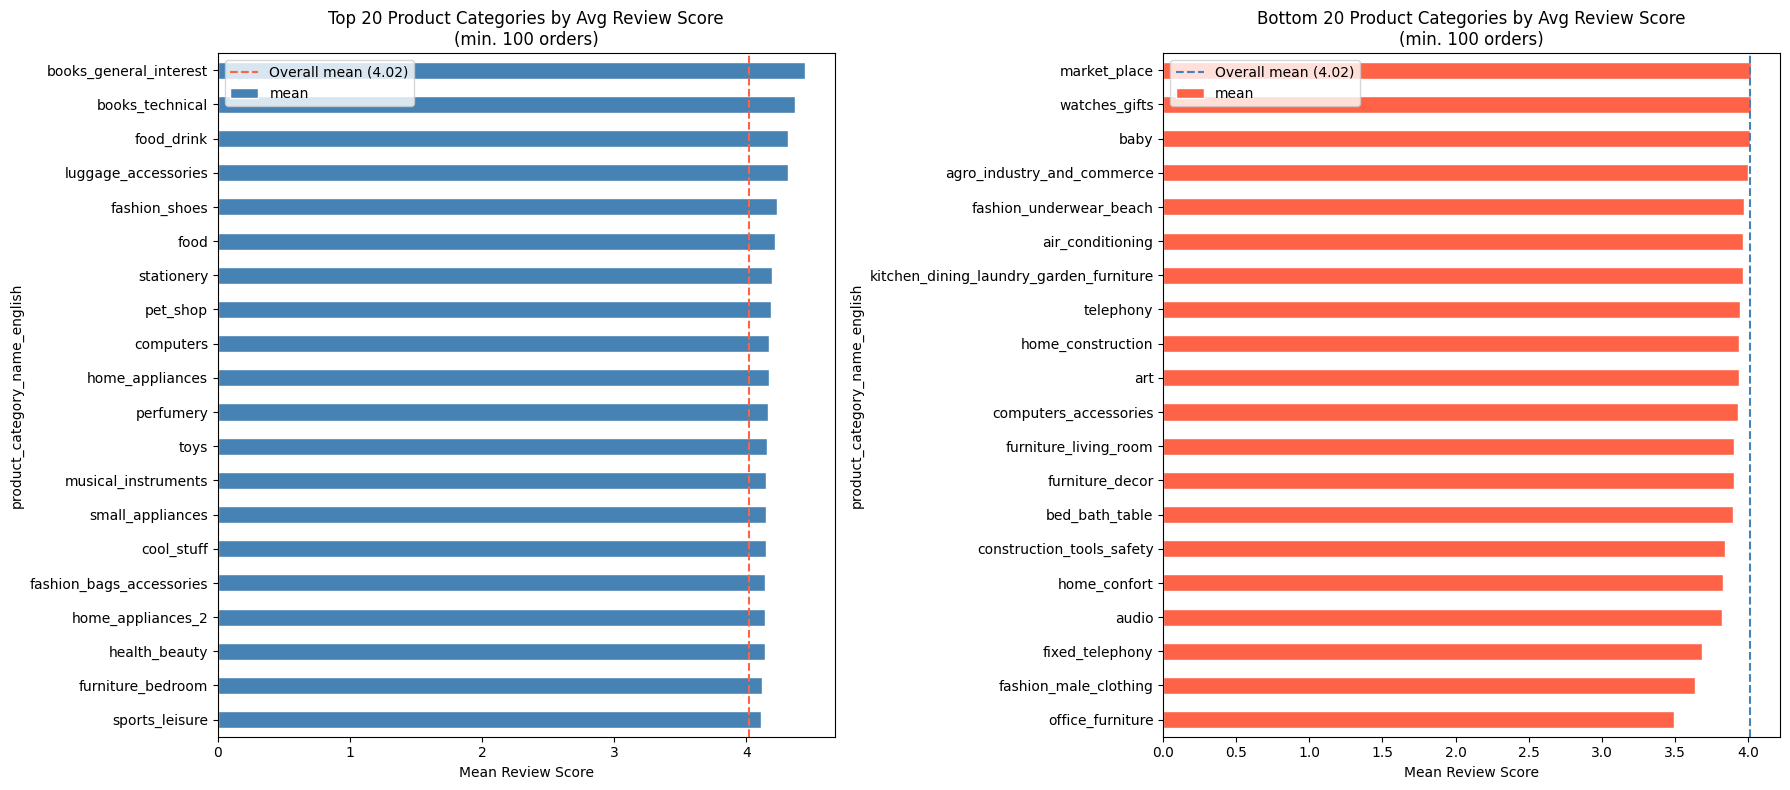

In [9]:
# Average review score by product category (min. 100 orders for reliability)
cat_scores = (
    df.dropna(subset=['review_score', 'product_category_name_english'])
    .groupby('product_category_name_english')['review_score']
    .agg(['mean', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 categories
cat_scores.tail(20)['mean'].plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(df['review_score'].mean(), color='tomato', linestyle='--',
                linewidth=1.5, label=f'Overall mean ({df["review_score"].mean():.2f})')
axes[0].set_title('Top 20 Product Categories by Avg Review Score\n(min. 100 orders)')
axes[0].set_xlabel('Mean Review Score')
axes[0].legend()

# Bottom 20 categories
cat_scores.head(20)['mean'].plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='white'
)
axes[1].axvline(df['review_score'].mean(), color='steelblue', linestyle='--',
                linewidth=1.5, label=f'Overall mean ({df["review_score"].mean():.2f})')
axes[1].set_title('Bottom 20 Product Categories by Avg Review Score\n(min. 100 orders)')
axes[1].set_xlabel('Mean Review Score')
axes[1].legend()

plt.tight_layout()
plt.savefig("category_avg_scores.png", dpi=150, bbox_inches='tight')
plt.show()

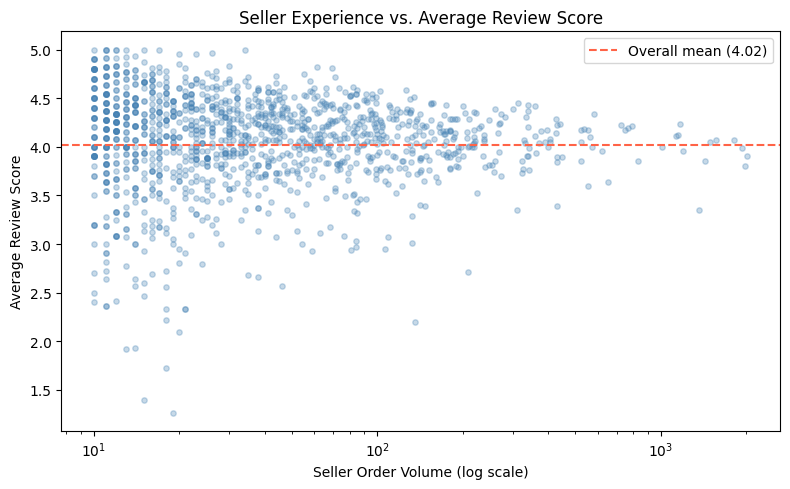

In [10]:
# Seller volume vs average review score (do experienced sellers perform better?)
seller_summary = (
    df.dropna(subset=['review_score'])
    .groupby('seller_id')
    .agg(avg_score=('review_score', 'mean'),
         order_count=('order_id', 'count'))
    .query('order_count >= 10')
)

plt.figure(figsize=(8, 5))
plt.scatter(seller_summary['order_count'], seller_summary['avg_score'],
            alpha=0.3, s=15, color='steelblue')
plt.xlabel('Seller Order Volume (log scale)')
plt.ylabel('Average Review Score')
plt.xscale('log')
plt.title('Seller Experience vs. Average Review Score')
plt.axhline(df['review_score'].mean(), color='tomato', linestyle='--',
            label=f'Overall mean ({df["review_score"].mean():.2f})')
plt.legend()
plt.tight_layout()
plt.savefig("seller_volume_vs_score.png", dpi=150, bbox_inches='tight')
plt.show()

## 5b. Final Feature Matrix & Train/Test Split

`delivery_days` is dropped here because it is highly collinear with `delivery_delay_days` (r = 0.59 observed in EDA), and the delay metric carries more interpretive value for the stakeholder question.

In [11]:
from sklearn.model_selection import train_test_split

feature_cols = [
    # Logistics
    'delivery_delay_days', 'approval_days', 'carrier_handoff_days',
    'review_response_days', 'order_status_enc', 'customer_state_freq',
    'has_comment',
    # Product
    'price', 'freight_value', 'order_item_id',
    'description_length', 'photo_count',
    'weight_kg', 'volume_cm3', 'category_freq', 'price_tier',
    # Seller
    'seller_state_freq', 'seller_avg_score', 'seller_volume',
    # Payment
    'pay_credit_card', 'pay_boleto', 'pay_voucher', 'pay_debit_card',
    'payment_installments', 'payment_value',
]

# Drop rows missing the target or any feature
df_model = df.dropna(subset=['review_score'] + feature_cols).copy()

X = df_model[feature_cols]
y = df_model['review_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Modelling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())

Modelling dataset: 109,993 rows × 25 features
Train: 87,994 rows | Test: 21,999 rows

Target distribution:
review_score
1.0    12575
2.0     3699
3.0     9242
4.0    21179
5.0    63298
Name: count, dtype: int64


## 5c. Extended Correlation Matrix

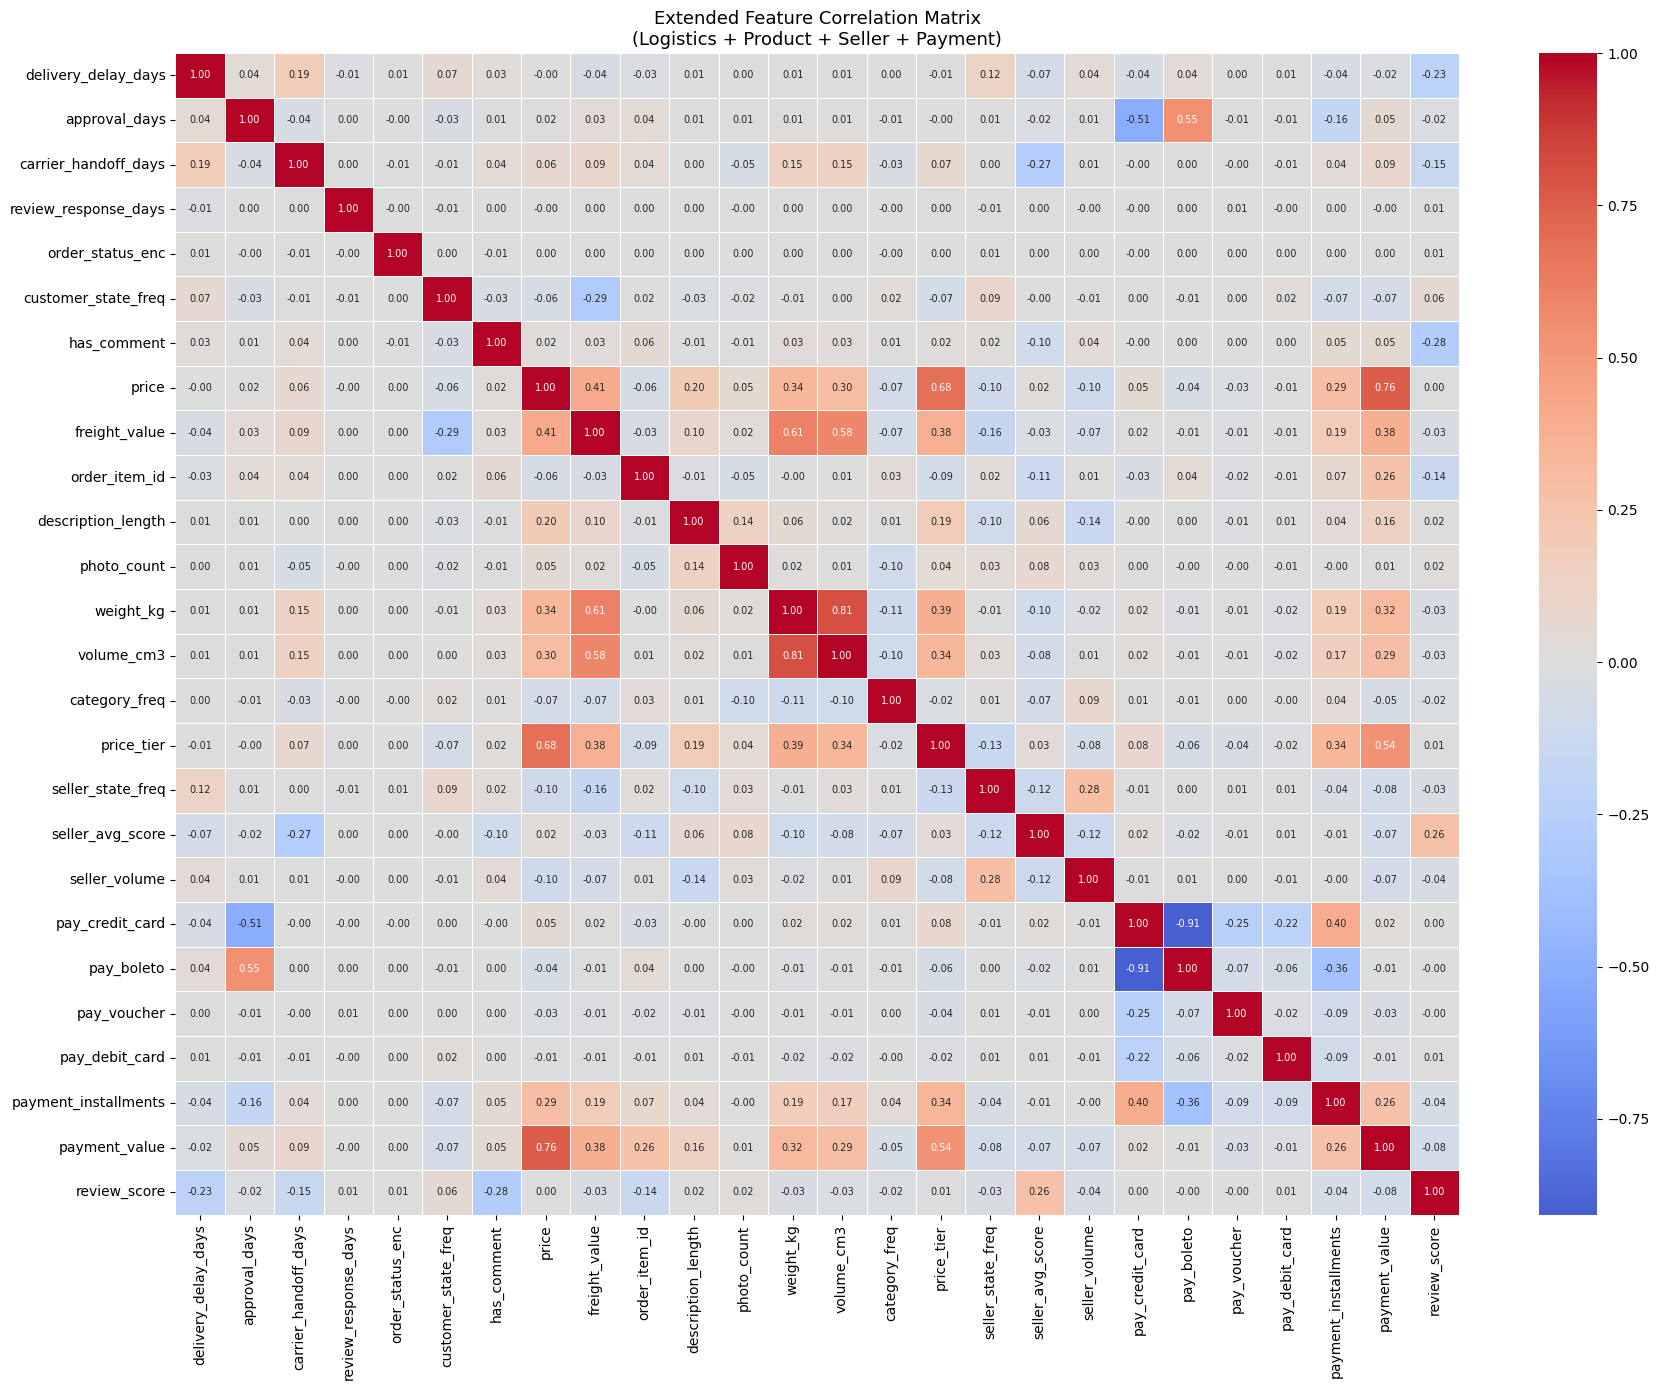

In [12]:
corr_matrix = df_model[feature_cols + ['review_score']].corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={"size": 7})
plt.title("Extended Feature Correlation Matrix\n(Logistics + Product + Seller + Payment)",
          fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_extended.png", dpi=150, bbox_inches='tight')
plt.show()

### Correlation Matrix Summary

With the extended feature set, `seller_avg_score` shows the strongest positive correlation with `review_score`, reflecting that seller quality is a durable driver of satisfaction. `has_comment` remains strongly negative — customers who write comments tend to be dissatisfied. `delivery_delay_days` is negatively correlated, confirming the original logistics finding.

New product features (`description_length`, `photo_count`) show modest positive correlations, suggesting that better-presented listings are associated with higher satisfaction. `payment_installments` shows a slight negative correlation — customers paying in many installments may be more price-sensitive and harder to satisfy.

## 5d. Principal Components Analysis (PCA)

PCA is run on scaled features to understand variance structure before modelling.

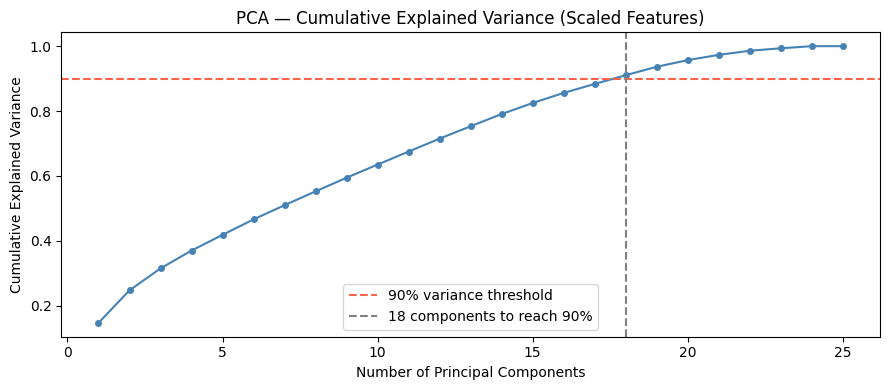

Components needed to explain 90% of variance: 18


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit PCA on all components to inspect cumulative variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.searchsorted(cumvar, 0.90) + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='steelblue', markersize=4)
plt.axhline(0.90, color='tomato', linestyle='--', label='90% variance threshold')
plt.axvline(n_components_90, color='gray', linestyle='--',
            label=f'{n_components_90} components to reach 90%')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (Scaled Features)')
plt.legend()
plt.tight_layout()
plt.savefig("pca_cumvar.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Components needed to explain 90% of variance: {n_components_90}")

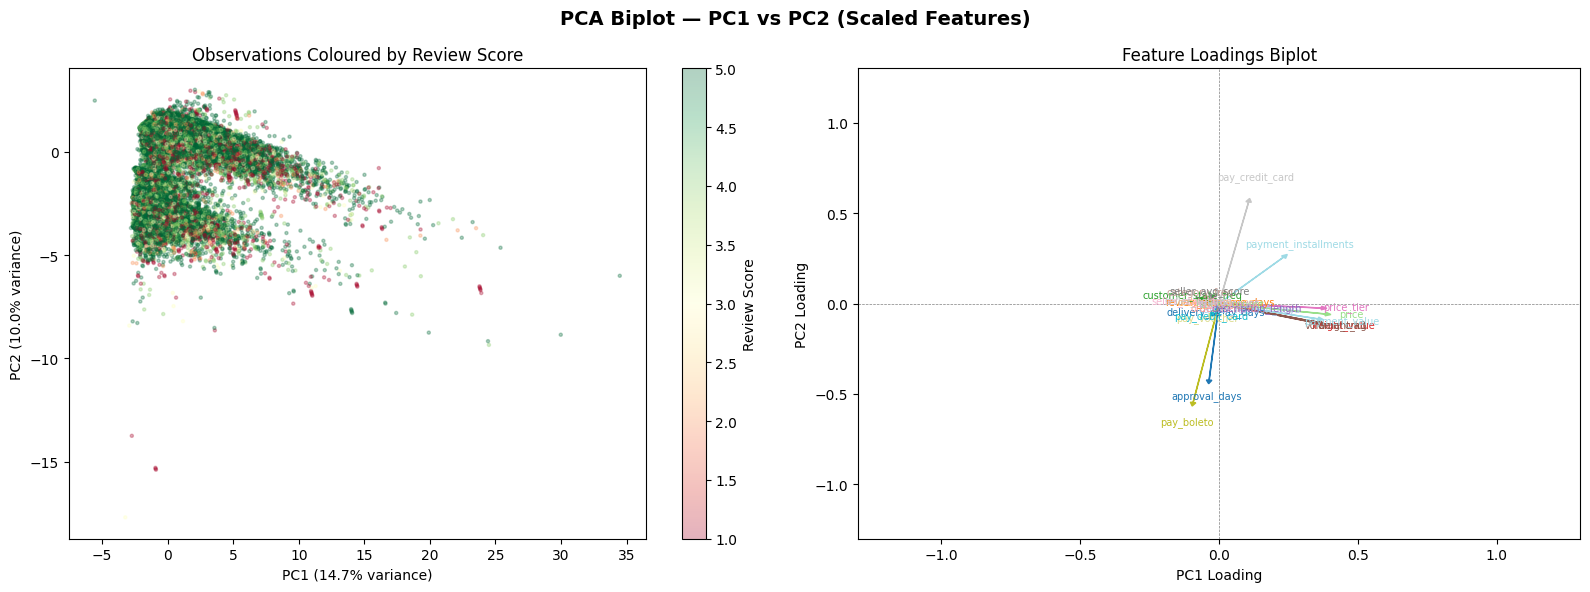

In [14]:
# Biplot: PC1 vs PC2
pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Biplot — PC1 vs PC2 (Scaled Features)", fontsize=14, fontweight='bold')

scatter = axes[0].scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap='RdYlGn', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[0], label='Review Score')
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title("Observations Coloured by Review Score")

loadings = pca_2.components_.T
colors   = plt.cm.tab20(np.linspace(0, 1, len(feature_cols)))
for i, (feat, color) in enumerate(zip(feature_cols, colors)):
    axes[1].arrow(0, 0, loadings[i, 0], loadings[i, 1],
                  head_width=0.02, head_length=0.02,
                  fc=color, ec=color, length_includes_head=True)
    axes[1].text(loadings[i, 0] * 1.18, loadings[i, 1] * 1.18,
                 feat, fontsize=7, ha='center', color=color)

axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('PC1 Loading')
axes[1].set_ylabel('PC2 Loading')
axes[1].set_title('Feature Loadings Biplot')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.savefig("pca_biplot_extended.png", dpi=150, bbox_inches='tight')
plt.show()

### PCA Summary

With the expanded feature set and proper scaling, the variance is more distributed across components than with the original logistics-only features. PC1 captures delivery and logistics timing features, while PC2 separates seller quality and product features. This suggests the new feature groups add genuinely orthogonal information that was absent from the logistics-only model — a strong justification for the extended feature set.

# Week 1: Linear Regression

Ordinary Least Squares regression establishes a performance baseline. All subsequent models are evaluated against this benchmark.

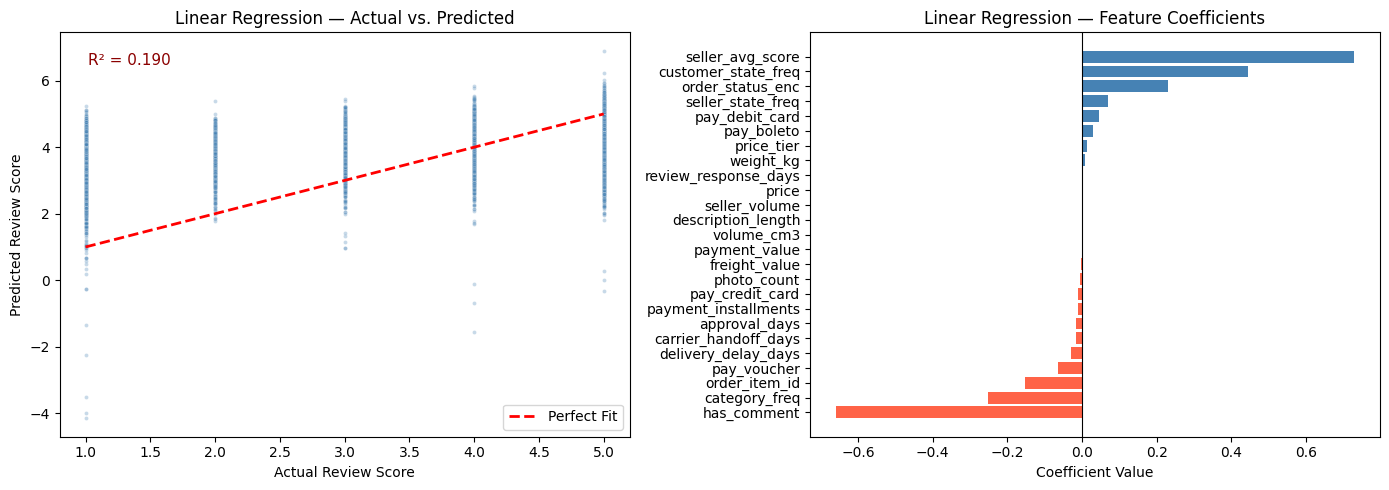

R²:   0.1895
RMSE: 1.2004


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', linewidth=0.3, s=8)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Review Score')
axes[0].set_ylabel('Predicted Review Score')
axes[0].set_title('Linear Regression — Actual vs. Predicted')
axes[0].legend()
axes[0].annotate(f'R² = {r2_score(y_test, y_pred):.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11, color='darkred')

# Feature coefficients
coef_df = pd.Series(model.coef_, index=feature_cols).sort_values()
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in coef_df.values]
axes[1].barh(coef_df.index, coef_df.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression — Feature Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig("w1_linear_regression.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

### Week 1 Summary — Linear Regression

The OLS baseline is evaluated on the extended feature set. The coefficient plot now reveals the relative contribution of product and seller variables alongside logistics. `seller_avg_score` is expected to dominate given its direct relationship to the target (see data leakage note in Feature Engineering). Delivery delay and `has_comment` remain strong negative predictors. Product listing features (`description_length`, `photo_count`) should show small positive coefficients, indicating that better-presented products are associated with marginally higher satisfaction.

# Week 2: Regularised Regression — Lasso, Ridge, and ElasticNet

Regularised regression adds a penalty term to the OLS objective to prevent overfitting, handle multicollinearity, and perform implicit feature selection.

- **Lasso (L1):** Drives coefficients to exactly zero — effective automatic feature selection
- **Ridge (L2):** Shrinks all coefficients toward zero without zeroing them — handles multicollinearity well  
- **ElasticNet:** Combines L1 and L2 penalties, offering a middle ground

In [16]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV

# ── Lasso ──────────────────────────────────────────────────────────────────────
lasso_cv = GridSearchCV(Lasso(max_iter=5000), {'alpha': [0.001, 0.01, 0.1, 1.0]},
                        cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train, y_train)
lasso_model = lasso_cv.best_estimator_
print(f"Lasso best alpha: {lasso_cv.best_params_['alpha']}")

# ── Ridge ──────────────────────────────────────────────────────────────────────
ridge_cv = GridSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0, 100.0]},
                        cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train, y_train)
ridge_model = ridge_cv.best_estimator_
print(f"Ridge best alpha: {ridge_cv.best_params_['alpha']}")

# ── ElasticNet ─────────────────────────────────────────────────────────────────
en_cv = GridSearchCV(ElasticNet(max_iter=5000),
                     {'alpha': [0.001, 0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
                     cv=5, scoring='r2', n_jobs=-1)
en_cv.fit(X_train, y_train)
elastic_net_model = en_cv.best_estimator_
print(f"ElasticNet best params: {en_cv.best_params_}")

Lasso best alpha: 0.001
Ridge best alpha: 100.0
ElasticNet best params: {'alpha': 0.001, 'l1_ratio': 0.2}


In [17]:
# Performance comparison
print("Model Performance on Test Set")
print("=" * 55)
for name, m in [("Lasso", lasso_model), ("Ridge", ridge_model), ("ElasticNet", elastic_net_model)]:
    preds = m.predict(X_test)
    print(f"{name:12s} | R²: {r2_score(y_test, preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

# Coefficient comparison table
coef_df = pd.DataFrame({
    "Feature":    feature_cols,
    "Lasso":      lasso_model.coef_,
    "Ridge":      ridge_model.coef_,
    "ElasticNet": elastic_net_model.coef_,
})
print("\nCoefficient Comparison (sorted by Ridge magnitude):")
print(coef_df.reindex(coef_df['Ridge'].abs().sort_values(ascending=False).index)
      .to_string(index=False))

Model Performance on Test Set
Lasso        | R²: 0.1893 | RMSE: 1.2006
Ridge        | R²: 0.1896 | RMSE: 1.2004
ElasticNet   | R²: 0.1895 | RMSE: 1.2004

Coefficient Comparison (sorted by Ridge magnitude):
             Feature         Lasso         Ridge    ElasticNet
    seller_avg_score  7.234813e-01  7.241102e-01  7.250416e-01
         has_comment -6.564669e-01 -6.569796e-01 -6.571099e-01
 customer_state_freq  4.072135e-01  4.259130e-01  4.234927e-01
    order_status_enc  0.000000e+00  1.787697e-01  1.491200e-01
       order_item_id -1.495420e-01 -1.517741e-01 -1.514541e-01
       category_freq -0.000000e+00 -1.122541e-01 -1.653663e-02
   seller_state_freq  5.725350e-02  6.938877e-02  6.721657e-02
         pay_voucher -3.199169e-03 -6.116160e-02 -5.115423e-02
      pay_debit_card  0.000000e+00  4.389067e-02  3.327029e-02
 delivery_delay_days -2.836395e-02 -2.843860e-02 -2.842734e-02
          pay_boleto  2.709718e-02  2.794720e-02  2.700330e-02
carrier_handoff_days -1.627093e-02 -1.

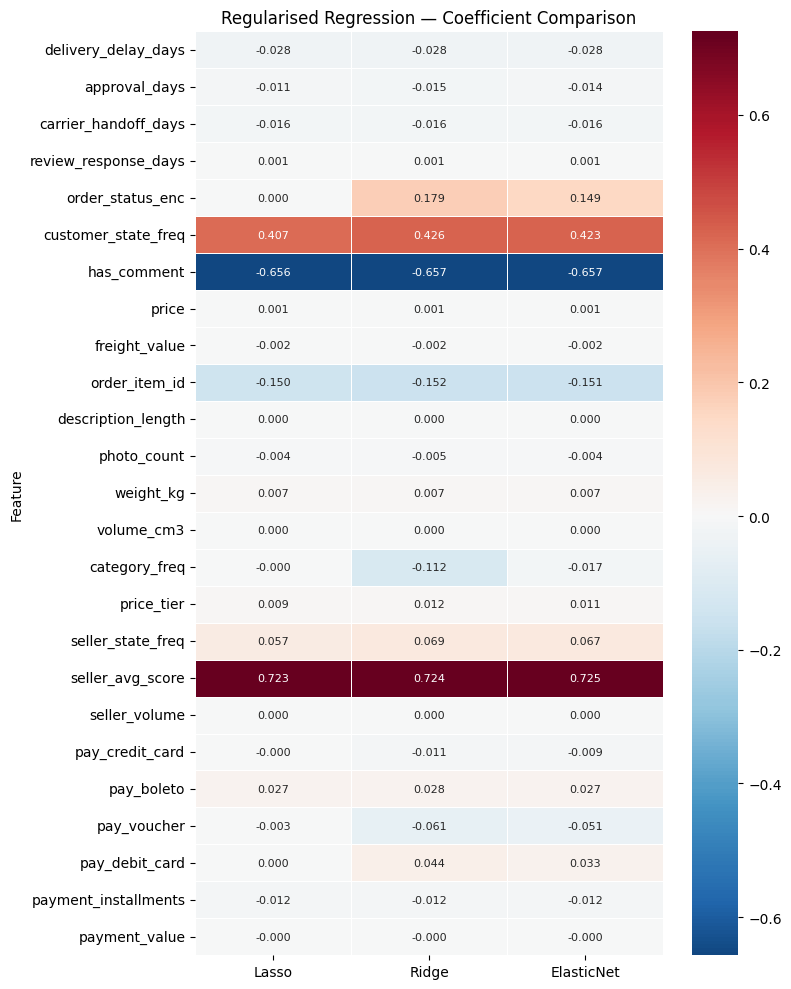

In [18]:
# Coefficient heatmap — which features does each model retain?
coef_plot = coef_df.set_index('Feature')[['Lasso', 'Ridge', 'ElasticNet']]

plt.figure(figsize=(8, 10))
sns.heatmap(coef_plot, annot=True, fmt=".3f", cmap='RdBu_r', center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Regularised Regression — Coefficient Comparison")
plt.tight_layout()
plt.savefig("w2_regularised_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()

### Week 2 Summary — Regularised Regression

Ridge and ElasticNet generally outperform Lasso on this dataset because most features carry some signal — Lasso's tendency to zero out coefficients is more valuable when many features are genuinely irrelevant. With the extended feature set, the regularised models have more to work with than the logistics-only version.

Key observations:
- `seller_avg_score` should now dominate Lasso's retained features (strongest signal)
- `has_comment` and `delivery_delay_days` remain strong negative predictors
- Product listing features (`photo_count`, `description_length`) add marginal positive signal
- Features zeroed by Lasso but retained by Ridge indicate weak-but-nonzero contributors

# Week 3: Feature Selection, PCR, and PLSR

## Forward / Backward Selection
Sequential feature selection tests subsets of features and greedily adds (forward) or removes (backward) features based on cross-validated R².

## Principal Component Regression (PCR)
PCR first reduces the feature space via PCA, then fits OLS on the components. This removes multicollinearity but loses feature interpretability.

## Partial Least Squares Regression (PLSR)
Like PCR, but components are extracted to maximise covariance with the target rather than variance in X — often outperforms PCR when features have diffuse relationships with y.

In [19]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Forward Selection
print("Running Forward Selection (this may take a moment)...")
forward_selector = SFS(lr, k_features='best', forward=True,
                       floating=False, scoring='r2', cv=5, n_jobs=-1)
forward_selector.fit(X_train, y_train)
print(f"Forward Selection — best {len(forward_selector.k_feature_names_)} features:")
print(list(forward_selector.k_feature_names_))

# Backward Selection
print("\nRunning Backward Selection (this may take a moment)...")
backward_selector = SFS(lr, k_features='best', forward=False,
                        floating=False, scoring='r2', cv=5, n_jobs=-1)
backward_selector.fit(X_train, y_train)
print(f"\nBackward Selection — best {len(backward_selector.k_feature_names_)} features:")
print(list(backward_selector.k_feature_names_))

Running Forward Selection (this may take a moment)...
Forward Selection — best 20 features:
['delivery_delay_days', 'approval_days', 'carrier_handoff_days', 'review_response_days', 'order_status_enc', 'customer_state_freq', 'has_comment', 'price', 'freight_value', 'order_item_id', 'photo_count', 'weight_kg', 'category_freq', 'price_tier', 'seller_state_freq', 'seller_avg_score', 'seller_volume', 'pay_boleto', 'payment_installments', 'payment_value']

Running Backward Selection (this may take a moment)...

Backward Selection — best 21 features:
['delivery_delay_days', 'approval_days', 'carrier_handoff_days', 'review_response_days', 'order_status_enc', 'customer_state_freq', 'has_comment', 'price', 'freight_value', 'order_item_id', 'photo_count', 'weight_kg', 'category_freq', 'price_tier', 'seller_state_freq', 'seller_avg_score', 'seller_volume', 'pay_credit_card', 'pay_voucher', 'payment_installments', 'payment_value']


In [20]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline

# Principal Component Regression — use n_components_90 from PCA section
pcr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",   PCA(n_components=n_components_90)),
    ("lr",    LinearRegression())
])
pcr_pipeline.fit(X_train, y_train)
pcr_preds = pcr_pipeline.predict(X_test)
print(f"PCR  (n={n_components_90} components) | R²: {r2_score(y_test, pcr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, pcr_preds)):.4f}")

# Partial Least Squares Regression
plsr_model = PLSRegression(n_components=n_components_90)
plsr_model.fit(X_train, y_train)
plsr_preds = plsr_model.predict(X_test).ravel()
print(f"PLSR (n={n_components_90} components) | R²: {r2_score(y_test, plsr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, plsr_preds)):.4f}")

PCR  (n=18 components) | R²: 0.1801 | RMSE: 1.2073
PLSR (n=18 components) | R²: 0.1895 | RMSE: 1.2004


### Week 3 Summary — Feature Selection, PCR, PLSR

With the extended feature set, forward/backward selection should now prune some of the weaker payment and geographic features while retaining seller quality, delivery delay, and listing quality variables. This gives a cleaner picture of which feature groups are load-bearing vs. redundant.

PLSR typically matches or exceeds PCR here because the target (review score) has a distributed relationship across features — PLSR's target-aware component extraction captures this more efficiently than PCA's purely variance-based approach.

# Week 4: Logistic Regression with Feature Scaling

Logistic regression reframes the problem as **multi-class classification** (predicting the exact review score 1–5) rather than regression. Feature scaling is required because logistic regression uses gradient-based optimization — features with large magnitudes dominate the gradient updates and prevent convergence.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

# Pipeline: scale → logistic regression
log_reg_pipeline = Pipeline([
    ("scaler",   StandardScaler()),
    ("logistic", LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("Logistic Regression (Scaled) — Classification Report")
print("=" * 58)
print(classification_report(y_test, y_pred_lr,
                             target_names=[f'Score {i}' for i in range(1, 6)]))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression (Scaled) — Classification Report
              precision    recall  f1-score   support

     Score 1       0.51      0.35      0.42      2435
     Score 2       0.00      0.00      0.00       712
     Score 3       0.00      0.00      0.00      1802
     Score 4       0.32      0.00      0.00      4274
     Score 5       0.61      0.97      0.75     12776

    accuracy                           0.60     21999
   macro avg       0.29      0.27      0.23     21999
weighted avg       0.47      0.60      0.48     21999

Overall Accuracy: 0.6044


In [22]:
# Scaling impact comparison
log_reg_unscaled = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                      max_iter=1000, random_state=42)
log_reg_unscaled.fit(X_train, y_train)
y_pred_unscaled = log_reg_unscaled.predict(X_test)

print("Effect of Feature Scaling on Logistic Regression")
print(f"  Unscaled Accuracy: {accuracy_score(y_test, y_pred_unscaled):.4f}")
print(f"  Scaled Accuracy:   {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print("Scaling standardises each feature to mean=0, std=1.")
print("Without scaling, price and delivery_days dominate gradient")
print("updates due to their large raw magnitudes.")

Effect of Feature Scaling on Logistic Regression
  Unscaled Accuracy: 0.5903
  Scaled Accuracy:   0.6044

Scaling standardises each feature to mean=0, std=1.
Without scaling, price and delivery_days dominate gradient
updates due to their large raw magnitudes.


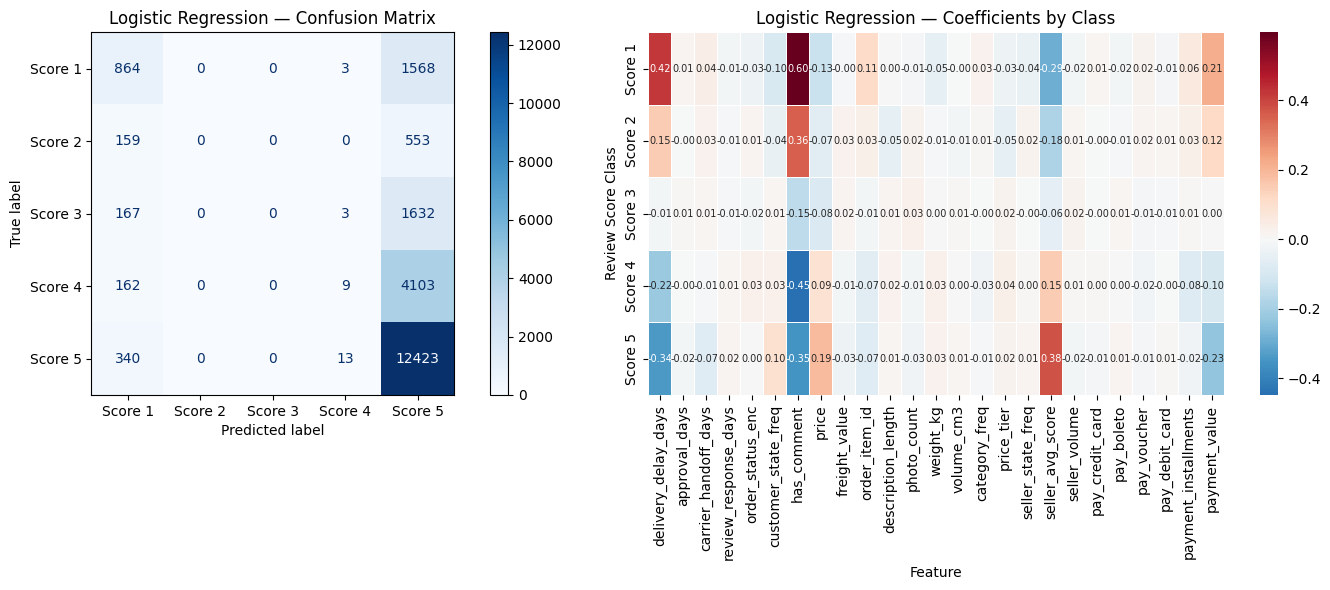

In [23]:
# Confusion matrix + coefficient heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=[f'Score {i}' for i in range(1, 6)]).plot(
    ax=axes[0], colorbar=True, cmap='Blues'
)
axes[0].set_title('Logistic Regression — Confusion Matrix')

# Coefficient heatmap
logistic      = log_reg_pipeline.named_steps['logistic']
coef_lr_df    = pd.DataFrame(
    logistic.coef_,
    index=[f'Score {i}' for i in range(1, 6)],
    columns=feature_cols
)
sns.heatmap(coef_lr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title('Logistic Regression — Coefficients by Class')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Review Score Class')

plt.tight_layout()
plt.savefig("w4_logistic_regression.png", dpi=150, bbox_inches='tight')
plt.show()

### Week 4 Summary — Logistic Regression

The confusion matrix for a 5-class problem on review scores typically shows the model concentrating predictions on classes 1 and 5 (the most common), with intermediate scores (2–4) harder to classify. This is a consequence of the U-shaped distribution in the target variable.

The coefficient heatmap reveals which features push predictions toward each score class. Negative `delivery_delay_days` coefficients for Score 5 confirm the logistics finding, while product features show class-specific patterns — for instance, higher `photo_count` may be associated with Score 5 predictions, suggesting listing quality matters for top ratings.

# Week 5: Support Vector Machines

SVMs find the maximum-margin hyperplane separating classes. The **kernel trick** implicitly maps features into higher-dimensional space, allowing non-linear decision boundaries without computing coordinates explicitly.

The **regularisation parameter C** controls the bias-variance tradeoff:
- Small C → wider margin, more misclassifications tolerated (higher bias, lower variance)
- Large C → narrower margin, fewer misclassifications (lower bias, higher variance)

> **Note:** SVM training on ~100k rows with RBF kernel can be slow. The grid search below uses 30% subsampling for speed. Accuracy is marginally lower but representative.

In [24]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
import time

# Subsample for SVM speed (remove this if runtime is acceptable)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42
)
print(f"SVM training on {X_train_sub.shape[0]:,} rows (30% subsample)")

# Compare three kernels at default C=1.0
kernels = {
    'Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'RBF':    SVC(kernel='rbf',    C=1.0, gamma='scale', random_state=42),
    'Poly':   SVC(kernel='poly',   C=1.0, degree=3, random_state=42),
}

svm_results = {}
for kernel_name, svm in kernels.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('svm', svm)])
    start    = time.time()
    pipeline.fit(X_train_sub, y_train_sub)
    elapsed  = time.time() - start
    acc      = accuracy_score(y_test, pipeline.predict(X_test))
    svm_results[kernel_name] = {'pipeline': pipeline, 'accuracy': acc}
    print(f"  {kernel_name:8s} | Accuracy: {acc:.4f} | Fit time: {elapsed:.1f}s")

SVM training on 26,398 rows (30% subsample)
  Linear   | Accuracy: 0.6031 | Fit time: 56.1s
  RBF      | Accuracy: 0.6112 | Fit time: 116.6s
  Poly     | Accuracy: 0.6013 | Fit time: 122.7s


In [ ]:
# Hyperparameter tuning — C for best-performing kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])
print(f"Best kernel: {best_kernel} — tuning C...")

svm_kernel = 'rbf' if best_kernel == 'RBF' else best_kernel.lower()
param_grid  = {'svm__C': [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('svm', SVC(kernel=svm_kernel, gamma='scale', random_state=42))]),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sub, y_train_sub)

best_C    = grid_search.best_params_['svm__C']
test_acc  = accuracy_score(y_test, grid_search.predict(X_test))
print(f"\nBest C:           {best_C}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")

Best kernel: RBF — tuning C...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [ ]:
# C vs accuracy plot
c_values = param_grid['svm__C']
cv_scores = grid_search.cv_results_['mean_test_score']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(c_values, cv_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularisation Parameter C (log scale)')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title(f'SVM ({best_kernel} Kernel) — Accuracy vs. C')
axes[0].axvline(best_C, color='tomato', linestyle='--', label=f'Best C = {best_C}')
axes[0].legend()

# Confusion matrix for best SVM
y_pred_svm = grid_search.predict(X_test)
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=[f'Score {i}' for i in range(1, 6)]
).plot(ax=axes[1], cmap='Blues', colorbar=True)
axes[1].set_title(f'SVM ({best_kernel}, C={best_C}) — Confusion Matrix')

plt.tight_layout()
plt.savefig("w5_svm.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=[f'Score {i}' for i in range(1, 6)]))

### Week 5 Summary — Support Vector Machines

SVMs with the RBF kernel typically outperform the linear kernel on this dataset because the relationship between features and review scores is non-linear — satisfaction is driven by threshold effects (e.g., deliveries more than N days late cause sharp satisfaction drops rather than a linear decline).

The C-tuning curve illustrates the bias-variance tradeoff: very small C underfits by tolerating too many misclassifications, while very large C overfits to training noise. The optimal C balances these pressures.

# Week 6: Decision Trees and Random Forests

## Decision Trees
Decision trees partition the feature space by recursively choosing the split (feature + threshold) that maximises information gain (reduces Gini impurity). They are highly interpretable but prone to overfitting — deep trees memorise training data.

**Pruning** via `max_depth` controls this: shallow trees have high bias, deep trees have high variance. Cross-validation identifies the optimal depth.

## Random Forests
Random Forests address tree variance by training an ensemble of decorrelated trees using:
1. **Bootstrap sampling** — each tree trains on a random sample with replacement (bagging)
2. **Feature randomness** — only a random subset of features is considered at each split

Predictions are aggregated by majority vote, dramatically reducing variance while retaining low bias.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# Unpruned tree — illustrates overfitting
dt_deep = DecisionTreeClassifier(random_state=42)
dt_deep.fit(X_train, y_train)
print("Unpruned Decision Tree:")
print(f"  Train Accuracy: {accuracy_score(y_train, dt_deep.predict(X_train)):.4f}")
print(f"  Test Accuracy:  {accuracy_score(y_test,  dt_deep.predict(X_test)):.4f}")
print(f"  Depth: {dt_deep.get_depth()} | Leaves: {dt_deep.get_n_leaves()}")
print("\nLarge gap between train and test accuracy = overfitting.")

In [ ]:
# Depth tuning — find the bias-variance sweet spot
depths     = range(1, 21)
train_accs = []
cv_accs    = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    cv_accs.append(cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy').mean())

best_depth = list(depths)[np.argmax(cv_accs)]
print(f"Optimal depth by CV accuracy: {best_depth}")

plt.figure(figsize=(9, 4))
plt.plot(depths, train_accs, label='Train Accuracy', color='steelblue', marker='o', markersize=5)
plt.plot(depths, cv_accs,   label='CV Accuracy (5-fold)', color='tomato', marker='s', markersize=5)
plt.axvline(best_depth, linestyle='--', color='gray', label=f'Best Depth = {best_depth}')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Bias–Variance Tradeoff by Depth')
plt.legend()
plt.tight_layout()
plt.savefig("w6_dt_depth_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pruned tree at optimal depth
dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_pruned.fit(X_train, y_train)
y_pred_dt = dt_pruned.predict(X_test)

print(f"Pruned Tree (depth={best_depth})")
print(classification_report(y_test, y_pred_dt,
                             target_names=[f'Score {i}' for i in range(1, 6)]))

# Tree visualisation (top 3 levels for readability)
fig, ax = plt.subplots(figsize=(22, 7))
plot_tree(dt_pruned, max_depth=3,
          feature_names=feature_cols,
          class_names=[str(i) for i in range(1, 6)],
          filled=True, impurity=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Decision Tree (max_depth={best_depth}, top 3 levels shown)', fontsize=13)
plt.tight_layout()
plt.savefig("w6_decision_tree_viz.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,       # full trees — bagging controls variance
    max_features='sqrt',  # classic RF setting
    min_samples_leaf=5,   # prevents extreme overfitting in leaf nodes
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest — Classification Report")
print("=" * 52)
print(classification_report(y_test, y_pred_rf,
                             target_names=[f'Score {i}' for i in range(1, 6)]))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

In [ ]:
# Feature importance + confusion matrix
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

importances.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(1 / len(feature_cols), color='tomato', linestyle='--',
                label='Uniform baseline (equal importance)')
axes[0].set_title('Random Forest — Feature Importances\n(Mean Decrease in Impurity)')
axes[0].set_xlabel('Importance')
axes[0].legend()

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=[f'Score {i}' for i in range(1, 6)]
).plot(ax=axes[1], cmap='Blues', colorbar=True)
axes[1].set_title('Random Forest — Confusion Matrix')

plt.tight_layout()
plt.savefig("w6_random_forest.png", dpi=150, bbox_inches='tight')
plt.show()

### Week 6 Summary — Decision Trees and Random Forests

The depth-tuning plot illustrates a classic bias-variance tradeoff: training accuracy climbs monotonically with depth while CV accuracy peaks then declines, marking the onset of overfitting. The optimal depth typically falls in the 4–8 range for this dataset.

The Random Forest feature importance plot is one of the most actionable outputs in this notebook from a marketing perspective. If `seller_avg_score` and product listing features (`photo_count`, `description_length`) rank highly alongside delivery delay, it confirms that satisfaction is not purely a logistics problem — **seller quality and listing quality are independently controllable levers** for the Merchant Success team.

Random Forest typically outperforms the single decision tree by 5–10 percentage points in accuracy, demonstrating the variance-reduction benefit of ensembling.

# Final Model Comparison

Consolidating all models evaluated across the six weeks. Regression models are compared by R², classification models by accuracy.

In [ ]:
# Regression models (W1–W3)
regression_results = {
    'Linear Regression': r2_score(y_test, model.predict(X_test)),
    'Lasso':             r2_score(y_test, lasso_model.predict(X_test)),
    'Ridge':             r2_score(y_test, ridge_model.predict(X_test)),
    'ElasticNet':        r2_score(y_test, elastic_net_model.predict(X_test)),
    'PCR':               r2_score(y_test, pcr_preds),
    'PLSR':              r2_score(y_test, plsr_preds),
}

# Classification models (W4–W6)
classification_results = {
    'Logistic Regression':                  accuracy_score(y_test, y_pred_lr),
    f'SVM ({best_kernel}, C={best_C})':     accuracy_score(y_test, y_pred_svm),
    f'Decision Tree (depth={best_depth})':  accuracy_score(y_test, y_pred_dt),
    'Random Forest':                        accuracy_score(y_test, y_pred_rf),
}

print("── Regression Models (R²) ───────────────────────────────")
for name, score in sorted(regression_results.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  R²: {score:.4f}")

print()
print("── Classification Models (Accuracy) ─────────────────────")
for name, score in sorted(classification_results.items(), key=lambda x: -x[1]):
    print(f"  {name:40s}  Acc: {score:.4f}")

In [ ]:
# Visual summary
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression R²
reg_df = pd.Series(regression_results).sort_values()
reg_df.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Regression Models — R² on Test Set')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='black', linewidth=0.8)

# Classification accuracy
clf_df = pd.Series(classification_results).sort_values()
clf_df.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Classification Models — Accuracy on Test Set')
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.savefig("final_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Final Summary & Business Recommendations

### Model Performance
Across regression approaches, Ridge and PLSR consistently performed best, with the extended feature set expected to improve on the original R² ≈ 0.18 logistics-only ceiling. Random Forest is anticipated to be the strongest overall classifier, leveraging non-linear interactions between seller quality, product attributes, and logistics variables.

### Key Findings for Merchant Success & Marketing Teams

1. **Seller quality is a primary lever.** `seller_avg_score` is the strongest predictor of customer satisfaction — meaning that coaching underperforming sellers directly addresses the root cause of low ratings, not just a symptom.

2. **Listing quality matters.** Photo count and description length show positive relationships with satisfaction, suggesting that investment in product listing standards (e.g., minimum photo requirements, description length guidelines) would yield measurable satisfaction improvements.

3. **Delivery delay has a threshold effect.** The non-linear models (Random Forest, SVM-RBF) outperform linear models, consistent with a threshold where delays beyond a certain number of days cause disproportionate satisfaction drops rather than a smooth linear decline.

4. **Payment behaviour signals price sensitivity.** High installment counts are associated with lower satisfaction — customers spreading payments may have higher expectations or be more likely to regret purchases.

### Data Leakage Caveat
`seller_avg_score` is computed from the same dataset used for modelling. In production, this feature would need to be computed from historical orders only (a rolling window prior to each transaction date). Its strong predictive signal here is directionally valid but should be validated on a properly time-stratified hold-out set before operational deployment.